In [1]:
from tcspc_lifetime import *
import glob
import numpy as np
from scipy.signal import fftconvolve
from scipy.optimize import least_squares
import matplotlib.pyplot as plt
import pandas as pd

# Load Data Files
The first example is loading Becker-Hickl ascii files. The files are expected to have time and photon counts columns. Files should be sorted to load data separately from instrument responses. Below we show loading data files that are ascii format and then instrument response files that are .sdt format.

In [2]:
data_pattern = './data/*.asc'
data_files = sorted(glob.glob(data_pattern))
loader = DataLoader()
data = loader.load_becker_hickl_ascii(data_files[0])
print(f"Found {len(data_files)} data files")

Found 1 data files


In [3]:
irf_pattern = './irf/*.sdt'
irf_files = sorted(glob.glob(irf_pattern))
loader = DataLoader()
irf = loader.load_becker_hickl_sdt(irf_files[0])
print(f"Found {len(irf_files)} IRF files")

Found 2 IRF files


# Check Files for Compatibility
The files should have the same TAC settings.

In [4]:
# Check that data and IRF have same time axis

# Load first data file
data = loader.load_becker_hickl_ascii(data_files[0])
data_time = data['time']

# Load first IRF file
irf = loader.load_becker_hickl_sdt(irf_files[0])
irf_time = irf['time']

# Verify
assert len(data_time) == len(irf_time), "Data and IRF must have same length!"
assert np.allclose(data_time, irf_time), "Data and IRF must have same time axis!"

print("✓ Files are compatible")

✓ Files are compatible


# Make a Plot for Inspection
The files available are stored in the files list. In the previous step we loaded the first file. We'll those for the rest of the analysis. A quick plot of irf and data are available in the TCSPC analysis routines. Alternatively, plots can be made with `matplotlib.pyplot`.

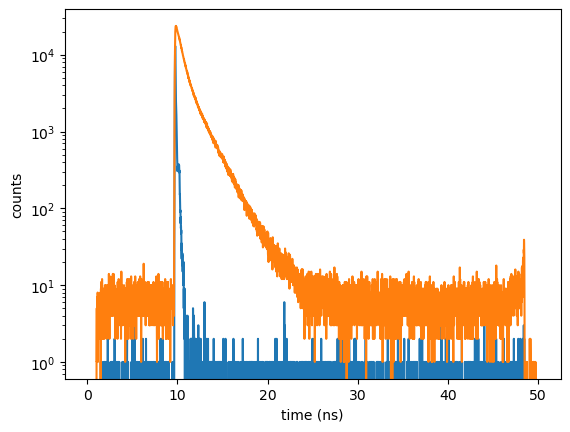

0

In [5]:
PlotRoutines.quick_plot(irf, data)

## `matplotlib.pyplot` version

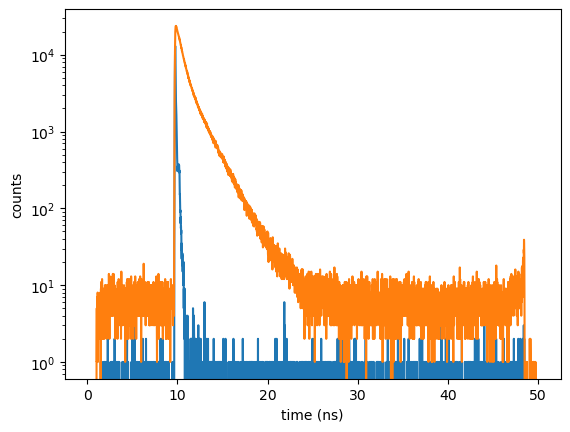

In [6]:
plt.semilogy(irf['time'], irf['counts'])
plt.semilogy(data['time'], data['counts'])
plt.xlabel('time (ns)')
plt.ylabel('counts')
plt.show()

# Truncate the Data & IRF
We need to remove the digitization artifacts at the beginning and end of the data and IRF. This can be done using indexes or times (in ns). The `trunc` function has a flag that is set to 1 for indexes and any other number for times. The `trunc` function returns a pandas dataframe with time, irf, and data columns (returned dataframe, `df['time'], df['irf'], df['data']`). The IRF will be normalized and have noise removed that falls below a threshold. In the figure above, the IRF noise is approximately 10 photon counts. Below is an example using time values to truncate from 8 to 45 ns and to remove IRF noise below 10 photon counts.

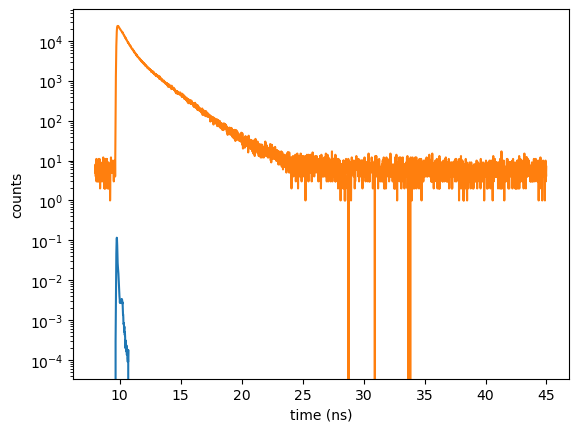

In [7]:
#df = DataFitting.trunc(data, irf, threshold, start time, end time, flag)
data4fit = DataFitting.trunc(data, irf, 10, 8, 45, 0)

plt.semilogy(data4fit['time'], data4fit['irf'])
plt.semilogy(data4fit['time'], data4fit['data'])
plt.xlabel('time (ns)')
plt.ylabel('counts')
plt.show()

# Initial Guesses
The fitting of this data requires making initial guesses to ensure proper fitting. Below, we plot the fit function based on initial guesses of two exponential lifetimes. It may take several attempts at changing the `initial_guesses` array to get the residuals to look evenly distributed. The fit function will fit as many exponentials as desired. The fit parameters `pw` are as follows.
```python
#The fit parameters are
# pw[0] = shift the IRF left (-) and right (+)
# pw [1] = baseline noise in photon counts
# pw[2] = amplitude of 1st lifetime
# pw[3] = lifetime 1 in ns
# pw[4] = amplitude of 2nd lifetime
# pw[5] = lifetime 2 in ns
...
# pw[2n] = amplitude n
# pw[2n+1] = lifetime n in ns
```

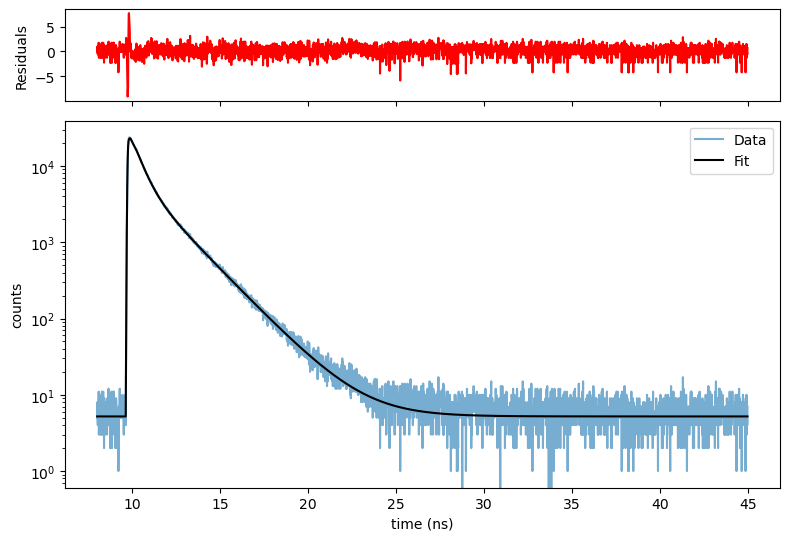

In [10]:
initial_guess = np.array([-2, 5.2, 1.15e11, 0.52, 6.0e5, 1.83]) #initial guesses at fit parameters
fit = DataFitting()
testy = fit.fit_multiexp(data4fit['time'], initial_guess) #create a fit array to visualize

PlotRoutines.full_figure(data4fit, initial_guess)

# Perform the Fit

In [11]:
initial_guess = np.array([-2, 5.2, 1.15e11, 0.52, 6.0e5, 1.83]) #initial guesses at fit parameters
result = least_squares(fit.residual_function, initial_guess, args=(data4fit['time'], data4fit['data']), method='lm', verbose=1)
optimal_params = np.array(result.x)
print("Optimized Fit Parmeters:", optimal_params)
print("Reduced Chi Squared = ", np.sum(result.fun**2)/(len(data4fit['data'])-len(initial_guess)))

`ftol` termination condition is satisfied.
Function evaluations 4, initial cost 2.0972e+03, final cost 2.0886e+03, first-order optimality 2.01e-03.
Optimized Fit Parmeters: [-2.00000000e+00  5.03991289e+00  1.15712176e+11  5.19744605e-01
  5.99066324e+05  1.83182268e+00]
Reduced Chi Squared =  1.3808972221843163


# Plot the Result

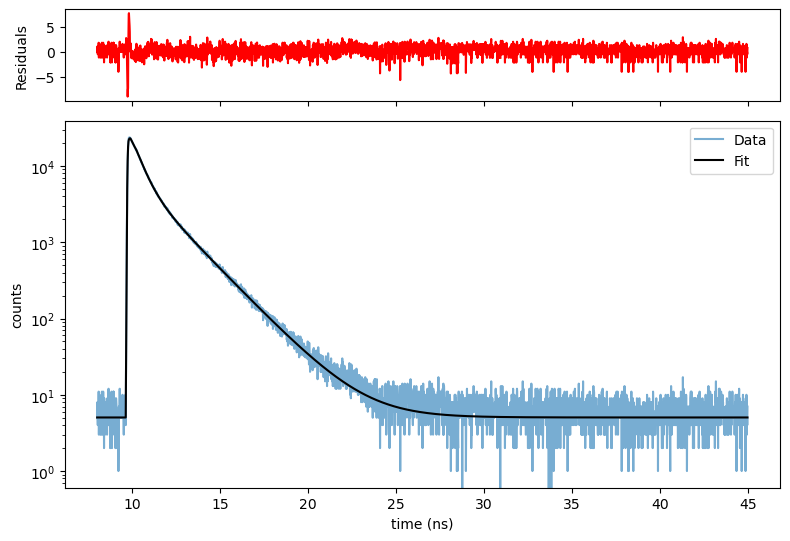

In [12]:
PlotRoutines.full_figure(data4fit, optimal_params)